In [25]:
import sklearn
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

In [4]:
ls

Untitled.ipynb       aligned_linkage.npy  kmeans.pkl


In [15]:
cluster_distances = np.load("aligned_linkage.npy")
clusters = np.argmin(cluster_distances, axis=-1)
unique, counts = np.unique(clusters, return_counts=True)
clusters_count = dict(zip(unique, counts))

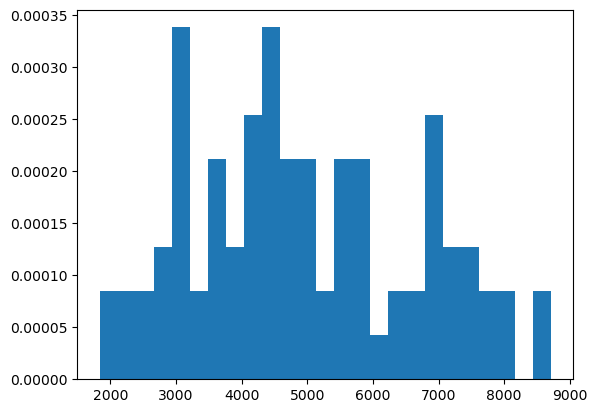

In [22]:
plt.hist(counts, density=True, bins=25)
plt.show()

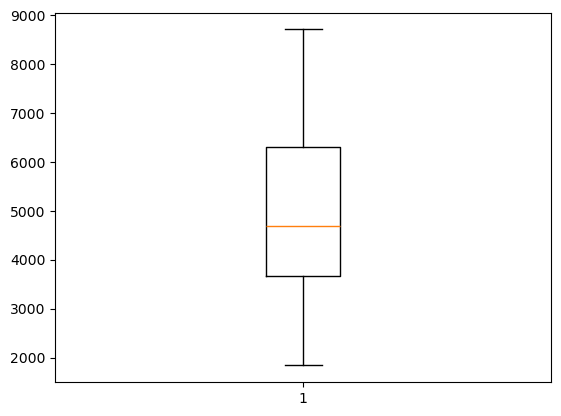

In [24]:
plt.boxplot(counts)
plt.show()

In [27]:
with open("kmeans.pkl", "rb") as f:
    kmeans = pkl.load(f)

/Users/gabdu45/opt/miniconda3/envs/mdanalysis/lib/python3.14/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [36]:
sorted(clusters_count)

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

In [35]:
np.array(list(zip(clusters, np.array(range(426066))))))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [37]:
clusters_count

{np.int64(0): np.int64(4777),
 np.int64(1): np.int64(5549),
 np.int64(2): np.int64(5592),
 np.int64(3): np.int64(7093),
 np.int64(4): np.int64(3963),
 np.int64(5): np.int64(3009),
 np.int64(6): np.int64(5935),
 np.int64(7): np.int64(3244),
 np.int64(8): np.int64(6225),
 np.int64(9): np.int64(4700),
 np.int64(10): np.int64(7945),
 np.int64(11): np.int64(2271),
 np.int64(12): np.int64(4273),
 np.int64(13): np.int64(2578),
 np.int64(14): np.int64(4086),
 np.int64(15): np.int64(6810),
 np.int64(16): np.int64(7529),
 np.int64(17): np.int64(4090),
 np.int64(18): np.int64(3716),
 np.int64(19): np.int64(5757),
 np.int64(20): np.int64(6892),
 np.int64(21): np.int64(3122),
 np.int64(22): np.int64(3083),
 np.int64(23): np.int64(2686),
 np.int64(24): np.int64(6974),
 np.int64(25): np.int64(4530),
 np.int64(26): np.int64(7712),
 np.int64(27): np.int64(4262),
 np.int64(28): np.int64(3049),
 np.int64(29): np.int64(4656),
 np.int64(30): np.int64(4423),
 np.int64(31): np.int64(2907),
 np.int64(32): np.

In [39]:
np.array(range(426066))[clusters == 85]

array([    36,     56,     97, ..., 425635, 425827, 425978], shape=(7568,))

In [51]:
distances_per_clusters = {}
all_avg = []
all_median = []
all_std = []
for i in range(86):
    dist = cluster_distances[np.array(range(426066))[clusters == i]]
    distances_per_clusters.update({i:{"dist":dist, "mean":np.mean(dist), "median":np.median(dist), "std":np.std(dist)}})
    all_avg.append(np.mean(dist))
    all_median.append(np.median(dist))
    all_std.append(np.std(dist))
    

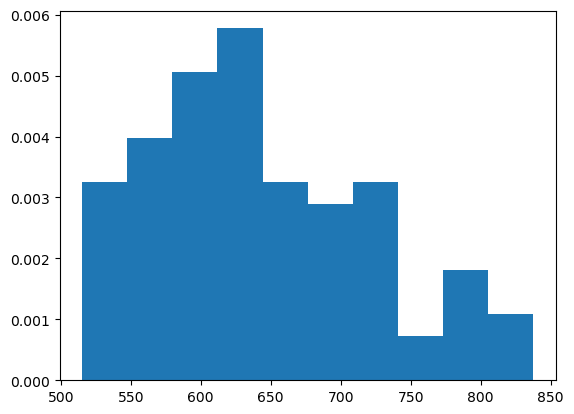

In [54]:
plt.hist(all_avg, density=True)
plt.show()

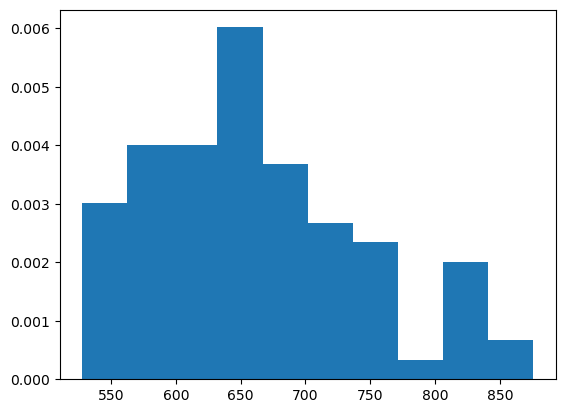

In [55]:
plt.hist(all_median, density=True)
plt.show()

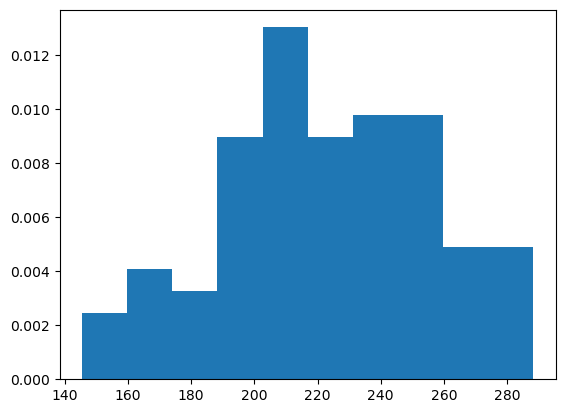

In [56]:
plt.hist(all_std, density=True)
plt.show()

In [58]:
kmeans.cluster_centers_

(86, 5037)

In [63]:
between_cluster_distances = sklearn.metrics.pairwise_distances(kmeans.cluster_centers_)

(array([  86.,  462.,  672., 1064., 1508., 1600., 1086.,  616.,  242.,
          60.]),
 array([   0.        ,  130.46020508,  260.92041016,  391.38061523,
         521.84082031,  652.30102539,  782.76123047,  913.22143555,
        1043.68164062, 1174.1418457 , 1304.60205078]),
 <BarContainer object of 10 artists>)

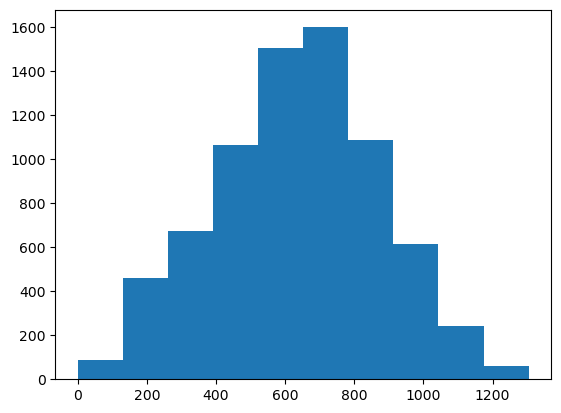

In [66]:
plt.hist(between_cluster_distances.flatten())

In [86]:
all_inertia = []
for i in range(20, 177):
    with open(f"cluster_85/multiple_kmeans/kmeans_{i}.pkl", "rb") as f:
        km = pkl.load(f)
        all_inertia.append(np.sqrt(km.inertia_))

/Users/gabdu45/opt/miniconda3/envs/mdanalysis/lib/python3.14/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [85]:
ls  cluster_85/multiple_kmeans/

kmeans_100.pkl  kmeans_132.pkl  kmeans_164.pkl  kmeans_39.pkl   kmeans_71.pkl
kmeans_101.pkl  kmeans_133.pkl  kmeans_165.pkl  kmeans_40.pkl   kmeans_72.pkl
kmeans_102.pkl  kmeans_134.pkl  kmeans_166.pkl  kmeans_41.pkl   kmeans_73.pkl
kmeans_103.pkl  kmeans_135.pkl  kmeans_167.pkl  kmeans_42.pkl   kmeans_74.pkl
kmeans_104.pkl  kmeans_136.pkl  kmeans_168.pkl  kmeans_43.pkl   kmeans_75.pkl
kmeans_105.pkl  kmeans_137.pkl  kmeans_169.pkl  kmeans_44.pkl   kmeans_76.pkl
kmeans_106.pkl  kmeans_138.pkl  kmeans_170.pkl  kmeans_45.pkl   kmeans_77.pkl
kmeans_107.pkl  kmeans_139.pkl  kmeans_171.pkl  kmeans_46.pkl   kmeans_78.pkl
kmeans_108.pkl  kmeans_140.pkl  kmeans_172.pkl  kmeans_47.pkl   kmeans_79.pkl
kmeans_109.pkl  kmeans_141.pkl  kmeans_173.pkl  kmeans_48.pkl   kmeans_80.pkl
kmeans_110.pkl  kmeans_142.pkl  kmeans_174.pkl  kmeans_49.pkl   kmeans_81.pkl
kmeans_111.pkl  kmeans_143.pkl  kmeans_175.pkl  kmeans_50.pkl   kmeans_82.pkl
kmeans_112.pkl  kmeans_144.pkl  kmeans_176.pkl  kmeans_51.pkl   

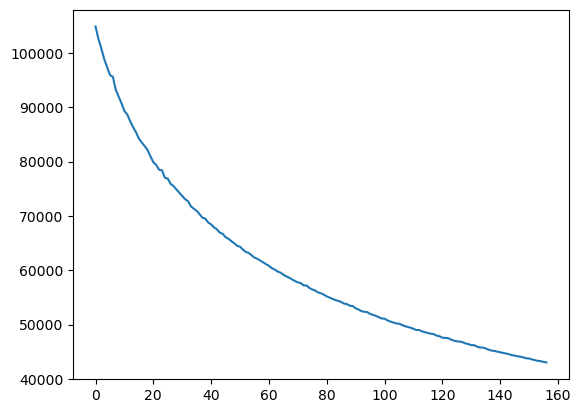

In [87]:
plt.plot(all_inertia)
plt.show()

In [73]:
len(all_inertia)

51

In [76]:
all_inertia

[10995307520.0,
 10524952576.0,
 10165864448.0,
 9775880192.0,
 9490916352.0,
 9199343616.0,
 9140021248.0,
 8690100224.0,
 8462023680.0,
 8228939264.0,
 7976027136.0,
 7859821568.0,
 7639264768.0,
 7450446848.0,
 7294794240.0,
 7096417280.0,
 6972768256.0,
 6863843328.0,
 6744842752.0,
 6556255744.0,
 6380988928.0,
 6303056896.0,
 6160229376.0,
 6144787968.0,
 5933367296.0,
 5906839040.0,
 5758628864.0,
 5699958272.0,
 5605015040.0,
 5517232640.0,
 5431875584.0,
 5339758592.0,
 5287086080.0,
 5150318592.0,
 5088082432.0,
 5031776768.0,
 4944872448.0,
 4852894208.0,
 4829822976.0,
 4730800128.0,
 4684065792.0,
 4608542720.0,
 4562649600.0,
 4478259712.0,
 4450795520.0,
 4366738432.0,
 4328500736.0,
 4271220224.0,
 4221741056.0,
 4159279104.0,
 4138446848.0,
 4071617536.0,
 4014354944.0,
 3993123840.0,
 3939003136.0,
 3884662784.0,
 3856388608.0,
 3815141888.0,
 3771306752.0,
 3736009216.0]

In [90]:
t = np.load("cluster_85/multiple_kmeans/linkage_mat_86.npy")

In [94]:
clusters = np.argmin(t, axis=-1)
unique_clusters = np.unique(clusters)

In [95]:
unique_clusters

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85])

In [96]:
import starfile

In [98]:
ls ..

cryoSPHERE_three/                    single_optics_group.star
j119-particles-0.84Apix-box512.star  single_optics_group_truncated.star


In [100]:
star_df = starfile.read("../single_optics_group.star")

In [104]:
star_df["particles"][clusters == 44]

,rlnCoordinateX,rlnCoordinateY,rlnAutopickFigureOfMerit,rlnImageName,rlnMicrographName,rlnOpticsGroup,rlnCtfMaxResolution,rlnCtfFigureOfMerit,rlnDefocusU,rlnDefocusV,...,rlnAnglePsi,rlnOriginXAngst,rlnOriginYAngst,rlnClassNumber,rlnNormCorrection,rlnLogLikeliContribution,rlnMaxValueProbDistribution,rlnNrOfSignificantSamples,rlnGroupNumber,rlnRandomSubset
134,1150.0,2590.0,6.715794,000135@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-1/FoilHole_1034...,1,3.336558,0.005730,23746.945312,23590.710938,...,-19.054370,6.631286,-15.314180,1,0.432306,111665.2,0.078676,18,13168,2
201,1920.0,2980.0,0.340635,000202@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-1/FoilHole_1034...,1,3.775579,-0.005170,29601.257812,29325.031250,...,27.341644,-7.724530,26.399152,1,0.422418,111767.6,0.074751,28,13173,1
319,730.0,2500.0,8.084842,000320@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-1/FoilHole_1034...,1,3.499317,0.006026,26146.261719,25938.048828,...,-165.645340,4.101404,-6.489310,1,0.415337,111173.4,0.140957,11,13180,2
500,4990.0,2230.0,1.113124,000501@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-1/FoilHole_1034...,1,3.432344,0.039742,13915.369141,13884.947266,...,-141.244870,-11.077890,-14.490700,1,0.419868,110996.5,0.306137,6,13189,1
525,4360.0,3420.0,0.088716,000526@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-1/FoilHole_1034...,1,3.836150,0.039400,16327.525391,16178.305664,...,-137.504720,7.866501,-10.666150,1,0.420918,111245.5,0.216344,8,13190,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425764,200.0,930.0,0.041332,425765@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-2/FoilHole_9404...,1,4.688627,-0.022790,28186.779297,27771.576172,...,-61.246490,12.926265,11.219860,1,0.251167,111457.7,0.130500,11,13131,1
425800,2330.0,890.0,3.508741,425801@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-2/FoilHole_9404...,1,3.660000,0.019449,12599.789062,12484.066406,...,99.062805,-12.784290,3.218475,1,0.436471,111007.7,0.344581,7,13134,1
425938,4550.0,3500.0,2.675300,425939@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-2/FoilHole_9404...,1,4.146590,0.088163,12223.761719,11980.569336,...,15.337606,-15.725910,5.748357,1,0.433108,111432.5,0.160786,17,13146,2
425972,2100.0,1640.0,8.022579,425973@j119-particles-0.84Apix-box512.mrcs,MotionCorr/job005/Movies/batch-2/FoilHole_9404...,1,3.941538,0.027913,14241.751953,13900.125977,...,42.901725,3.630214,5.748357,1,0.426005,110997.6,0.222168,8,13148,1
